In [1]:
# DBSCAN
# DBSCAN = Density-Based Spatial Clustering of Applications with Noise.

# Unlike K-Means or Hierarchical clustering, DBSCAN:

# does NOT ask you for K — it figures out the number of clusters automatically.
# can find non-spherical / non-convex clusters (moons, circles, spirals).
# labels outliers as noise (label = -1) instead of forcing them into a cluster.

In [ ]:
# eps:The radius of the neighbourhood around a point. "How close is close?"
# min_samples:Minimum points needed inside eps to call a region dense.

# Three kinds of points DBSCAN sees
# Core point — has at least min_samples neighbours within eps.
# Border point — fewer than min_samples neighbours, but is within eps of a core point.
# Noise point — neither core nor border → outlier (label -1).


# algorithm in 3 lines
# Pick any unvisited point. Count neighbours inside eps.
# If it has ≥ min_samples neighbours, start a new cluster and add all density-reachable points to it.
# Else mark it as noise (it may later get picked up as a border point).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [3]:
# Load the data

df = pd.read_csv('moons.csv')
print('Shape:', df.shape)
df.head()

Shape: (210, 2)


,x,y
0,-1.037932,0.092873
1,0.916021,0.457636
2,0.641441,0.722593
3,1.204447,-0.401991
4,0.305301,-0.165425


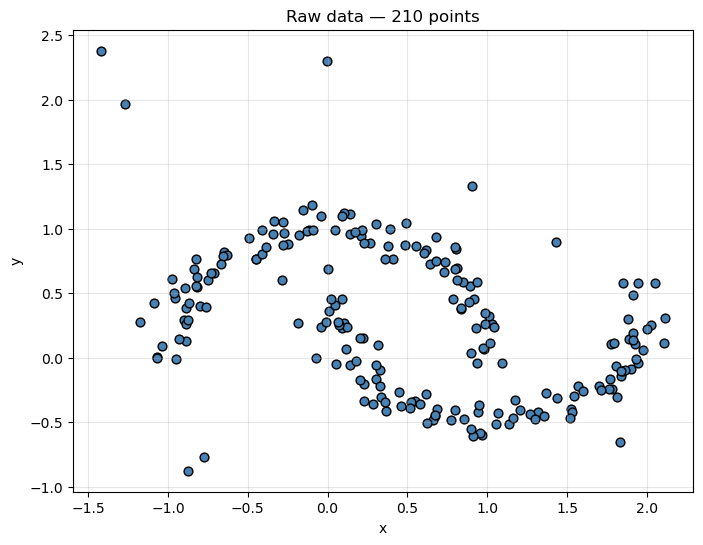

In [4]:
# Look at the raw data

plt.figure(figsize=(8, 6))
plt.scatter(df['x'], df['y'], s=40, c='steelblue', edgecolor='black')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Raw data — 210 points')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
 # Scale the features

X = df[['x', 'y']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled first 3 rows:\n', X_scaled[:3].round(2))

Scaled first 3 rows:
 [[-1.7  -0.34]
 [ 0.49  0.31]
 [ 0.18  0.78]]


In [6]:
# Fit DBSCAN

db = DBSCAN(eps=0.30, min_samples=5)
labels = db.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int((labels == -1).sum())

print(f'Number of clusters found : {n_clusters}')
print(f'Number of noise points   : {n_noise}')
print(f'Labels (first 20)        : {labels[:20]}')

Number of clusters found : 2
Number of noise points   : 14
Labels (first 20)        : [0 0 0 1 1 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0]


In [7]:
# Attach the labels and count cluster sizes

df['cluster'] = labels
df['cluster'].value_counts().sort_index()

cluster
-1     14
 0    100
 1     96
Name: count, dtype: int64

In [8]:
# Plot the final clusters

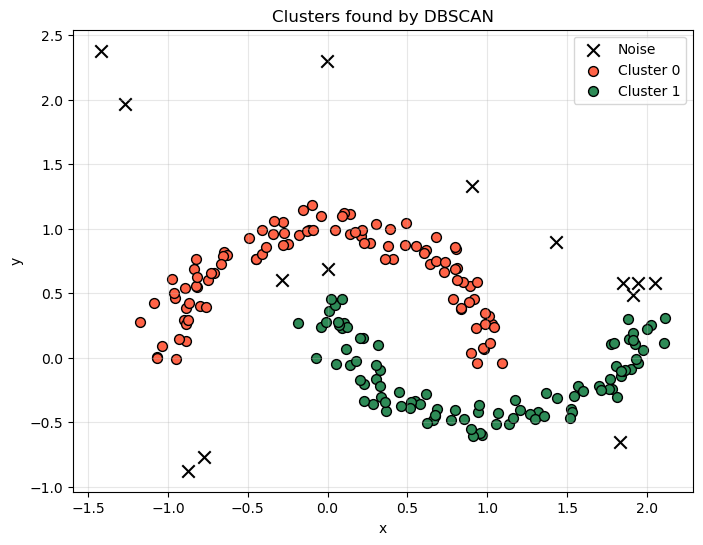

In [9]:
plt.figure(figsize=(8, 6))
colors = ['tomato', 'seagreen', 'royalblue', 'orange', 'purple']

for c in sorted(df['cluster'].unique()):
    mask = labels == c
    if c == -1:
        plt.scatter(X[mask, 0], X[mask, 1],
                    s=80, c='black', marker='x',
                    label='Noise')
    else:
        plt.scatter(X[mask, 0], X[mask, 1],
                    s=50, c=colors[c % len(colors)], edgecolor='black',
                    label=f'Cluster {c}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Clusters found by DBSCAN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

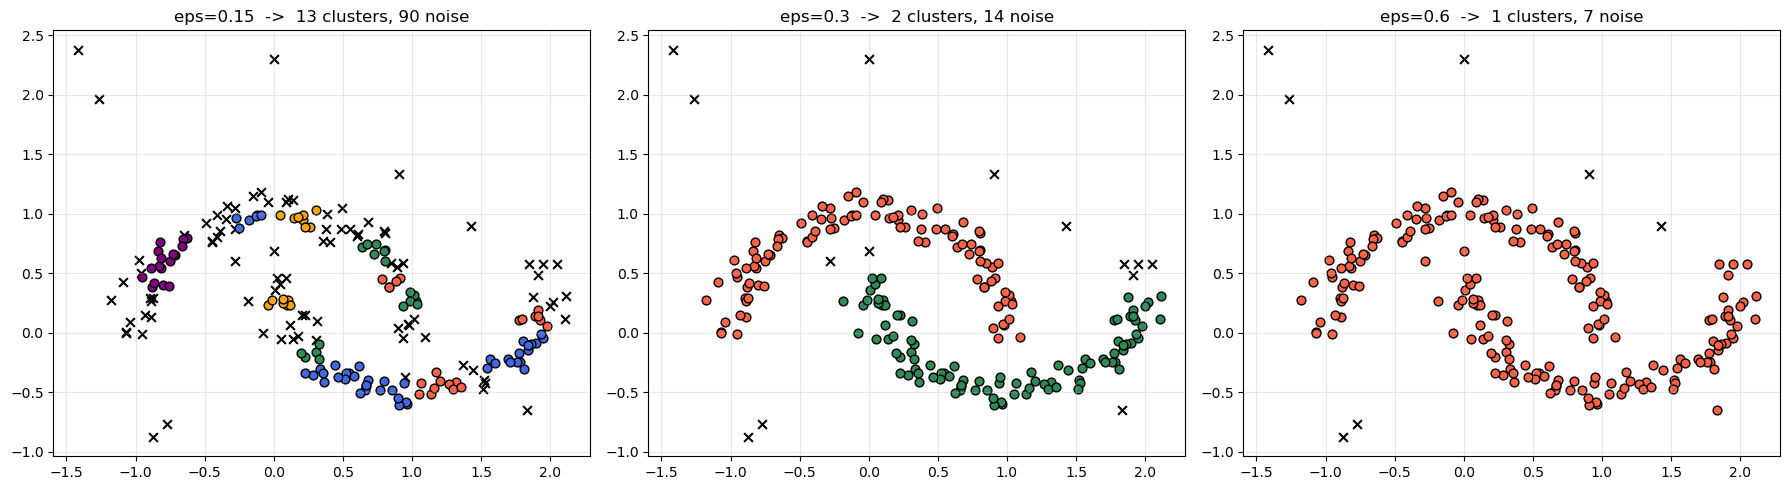

In [10]:
# Play with the parameters

eps_values = [0.15, 0.30, 0.60]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, eps in zip(axes, eps_values):
    lbls = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    n_c = len(set(lbls)) - (1 if -1 in lbls else 0)
    n_n = int((lbls == -1).sum())

    for c in sorted(set(lbls)):
        m = lbls == c
        if c == -1:
            ax.scatter(X[m, 0], X[m, 1], s=40, c='black', marker='x')
        else:
            ax.scatter(X[m, 0], X[m, 1], s=40,
                       c=colors[c % len(colors)], edgecolor='black')
    ax.set_title(f'eps={eps}  ->  {n_c} clusters, {n_n} noise')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Recap
# Load the clean CSV with pd.read_csv.
# Scale the features with StandardScaler (distance-based algorithm).
# Use a k-distance plot to choose eps (look for the elbow).
# Fit sklearn.cluster.DBSCAN(eps=..., min_samples=...).
# Call .fit_predict(X_scaled) → labels (-1 means noise / outlier).
# Visualise.


# When to prefer DBSCAN over K-Means / Hierarchical
# You don't know K in advance.
# Clusters have odd shapes (moons, circles, spirals).
# You expect outliers and want them flagged, not absorbed into a cluster.


# When DBSCAN struggles
# Clusters have very different densities (one parameter eps can't fit all).
# High-dimensional data (distance becomes meaningless — the curse of dimensionality).
# Click to add a cell.